### Intel Lab Data

[https://db.csail.mit.edu/labdata/labdata.html]

`mote_locs.txt` contains the locations: id, x, y. 
`data` ontains 2.3 million readings from sensors. Data is in the form: 
- date: yyyy-mm-dd
- time: hh:mm:ss.xxx
- epoch: int
- moteid: int
- temperature: real (Celsius)
- humidity: real
- light: real
- voltage: real


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [35]:
position_data = pd.read_table('mote_locs.txt', names = ['mote_id', 'x', 'y'], sep=' ')
position_data.head()

,mote_id,x,y
0,1,21.5,23
1,2,24.5,20
2,3,19.5,19
3,4,22.5,15
4,5,24.5,12


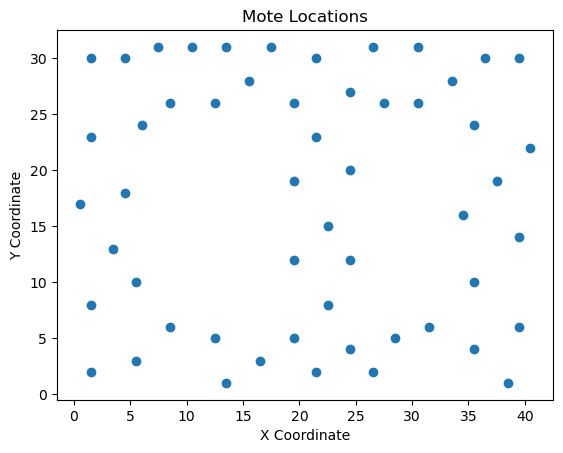

In [36]:
plt.scatter(position_data['x'], position_data['y'])
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Mote Locations')

plt.show()

In [37]:
### Read data and preprocess
data = pd.read_table('data', names = ['date', 'time', 'epoch', 'mote_id', 'temperature', 'humidity', 'light', 'voltage'], sep=' ')

print(data.info())

# Convert 'date' and 'time' columns to seconds since start of data collection
data['datetime'] = pd.to_datetime(data['date'] + ' ' + data['time'], format='mixed')
data['seconds_since_start'] = (data['datetime'] - data['datetime'].min()).dt.total_seconds()

# Drop unnecessary columns
data.drop(columns=['light', 'humidity', 'voltage', 'date', 'time', 'datetime'], inplace=True)

# # only keep the first NT time steps for the animation
# NT = 1000
# data = data[data["epoch"] < NT]

data["seconds_since_start"] = (np.floor(data["seconds_since_start"]).astype("int32"))
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2313682 entries, 0 to 2313681
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   date         object 
 1   time         object 
 2   epoch        int64  
 3   mote_id      float64
 4   temperature  float64
 5   humidity     float64
 6   light        float64
 7   voltage      float64
dtypes: float64(5), int64(1), object(2)
memory usage: 141.2+ MB
None


,epoch,mote_id,temperature,seconds_since_start
0,2,1.0,122.1530,2774400
1,3,1.0,19.9884,60
2,11,1.0,19.3024,301
3,17,1.0,19.1652,480
4,18,1.0,19.1750,511


In [38]:
sensor1 = data[data["mote_id"] == 1]
sensor1["delta_time"] = sensor1["seconds_since_start"].diff().fillna(0)

/var/folders/m9/f9n7lrs55wx3y8njmz990pvh0000gn/T/ipykernel_49404/1867420151.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sensor1["delta_time"] = sensor1["seconds_since_start"].diff().fillna(0)


<class 'pandas.core.frame.DataFrame'>
Index: 43047 entries, 0 to 43046
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   epoch                43047 non-null  int64  
 1   mote_id              43047 non-null  float64
 2   temperature          43047 non-null  float64
 3   seconds_since_start  43047 non-null  int32  
 4   delta_time           43047 non-null  float64
dtypes: float64(3), int32(1), int64(1)
memory usage: 1.8 MB


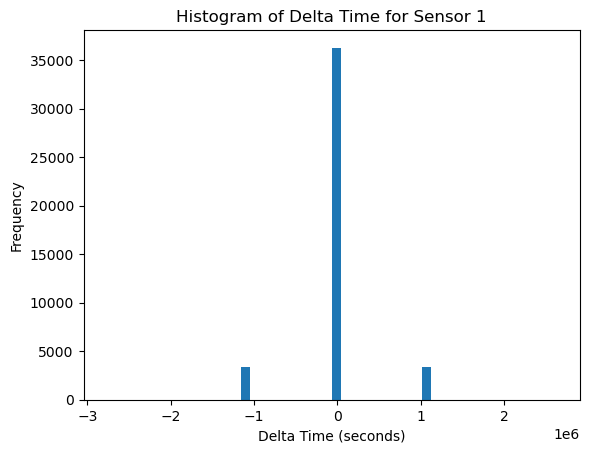

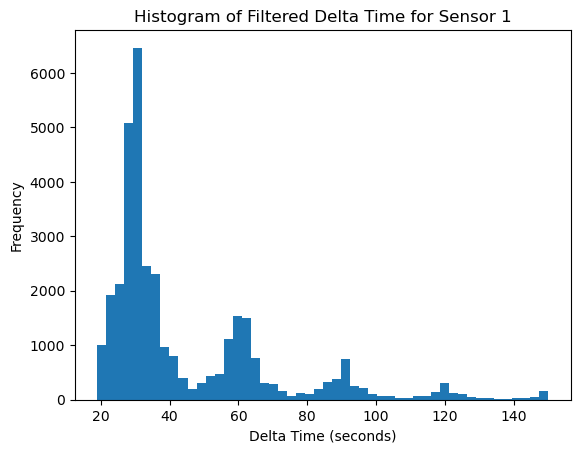

In [39]:
sensor1.info()

## histogram of seconds_since_start
plt.hist(sensor1["delta_time"], bins=50)
plt.xlabel("Delta Time (seconds)")
plt.ylabel("Frequency")
plt.title("Histogram of Delta Time for Sensor 1")
plt.show()


# remove outliers in delta_time for sensor 1. Remove smallest biggest 5% of the data
lower_bound = sensor1["delta_time"].quantile(0.1)
upper_bound = sensor1["delta_time"].quantile(0.9)
sensor1_filtered = sensor1[(sensor1["delta_time"] >= lower_bound) & (sensor1["delta_time"] <= upper_bound)]

# histogram of filtered delta_time
plt.hist(sensor1_filtered["delta_time"], bins=50)
plt.xlabel("Delta Time (seconds)")
plt.ylabel("Frequency")
plt.title("Histogram of Filtered Delta Time for Sensor 1")
plt.show()


In [40]:
display(data[data["epoch"] == 0])


,epoch,mote_id,temperature,seconds_since_start
385284,0,11.0,21.7720,1966103
427119,0,12.0,19.5964,1966089
619541,0,19.0,122.1530,1966098
687835,0,21.0,88.2062,1966090
1991240,0,47.0,21.8798,1966093
2205708,0,52.0,22.0856,1966115


In [41]:
# average datapoints over a minute (60 seconds) for each sensor
data["minute"] = (data["seconds_since_start"] // 60).astype("int32")
data_avg = data.groupby(["mote_id", "minute"]).mean().reset_index()

In [42]:
data_avg.drop(columns=["epoch", "seconds_since_start"], inplace=True)
data_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546027 entries, 0 to 1546026
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   mote_id      1546027 non-null  float64
 1   minute       1546027 non-null  int32  
 2   temperature  1545746 non-null  float64
dtypes: float64(2), int32(1)
memory usage: 29.5 MB


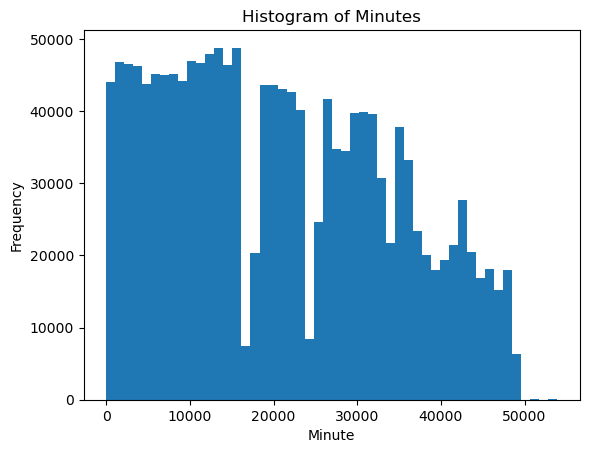

In [43]:
## histogram of minutes
plt.hist(data_avg["minute"], bins=50)
plt.xlabel("Minute")
plt.ylabel("Frequency")
plt.title("Histogram of Minutes")
plt.show()

In [44]:
# filter out first 1000 minutes
data_avg = data_avg[data_avg["minute"] < 1000]

In [ ]:
# data_avg.to_feather("intel_data_processed_1000.feather", compression="zstd")

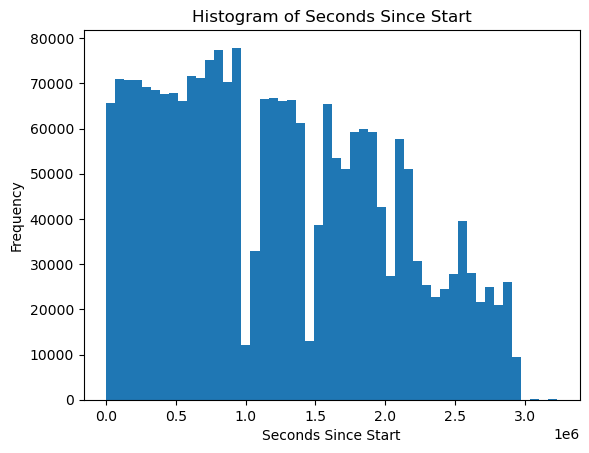

In [31]:
## histogram of seconds_since_start
plt.hist(data["seconds_since_start"], bins=50)
plt.xlabel("Seconds Since Start")
plt.ylabel("Frequency")
plt.title("Histogram of Seconds Since Start")
plt.show()

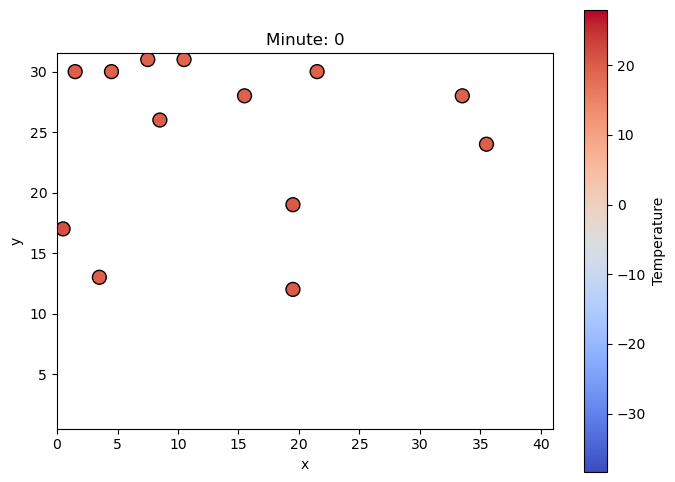

In [32]:

DATA = data_avg.copy()
# ---------------------------------------------------------
# 1. Combine temperature measurements with sensor positions
# ---------------------------------------------------------
df = DATA.merge(position_data, on="mote_id", how="left")



# Sort for convenience
df = df.sort_values(["minute", "mote_id"])

# All unique time steps
minutes = np.sort(df["minute"].unique())

# ---------------------------------------------------------
# 2. Set up plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Use a fixed color scale across the entire animation.
# This is important so that colors mean the same thing
# at every time step.
vmin = df["temperature"].min()
vmax = df["temperature"].max()

# Data at first time step
first = df[df["minute"] == minutes[0]]

scatter = ax.scatter(
    first["x"],
    first["y"],
    c=first["temperature"],
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    s=100,
    edgecolors="black"
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Temperature")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Minute: {minutes[0]}")

# Keep spatial extent fixed
ax.set_xlim(df["x"].min() - 0.5, df["x"].max() + 0.5)
ax.set_ylim(df["y"].min() - 0.5, df["y"].max() + 0.5)

ax.set_aspect("equal")


# ---------------------------------------------------------
# 3. Animation update function
# ---------------------------------------------------------
def update(frame):
    minute = minutes[frame]

    current = df[df["minute"] == minute]

    # Update sensor positions
    scatter.set_offsets(
        current[["x", "y"]].to_numpy()
    )

    # Update temperatures/colors
    scatter.set_array(
        current["temperature"].to_numpy()
    )

    ax.set_title(f"Minute: {minute}")

    return scatter,


# ---------------------------------------------------------
# 4. Create animation
# ---------------------------------------------------------
anim = FuncAnimation(
    fig,
    update,
    frames=len(minutes),
    interval=100,   # milliseconds between frames
    blit=False
)

plt.show()

In [ ]:
anim.save(
    "temperature_animation_2.gif",
    writer="pillow",
    fps=10
)